In [161]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker

# Ellipse

In [162]:
flat_source, flat_target, hl, f1, L = np.loadtxt('dataell/input.csv', delimiter = ',')
print(f"flat source = {bool(flat_source)}, flat target = {bool(flat_target)}, half-length = {hl}, f1 = {f1}, L = {L}")

flat source = True, flat target = False, half-length = 0.001, f1 = 1.0, L = 30.0


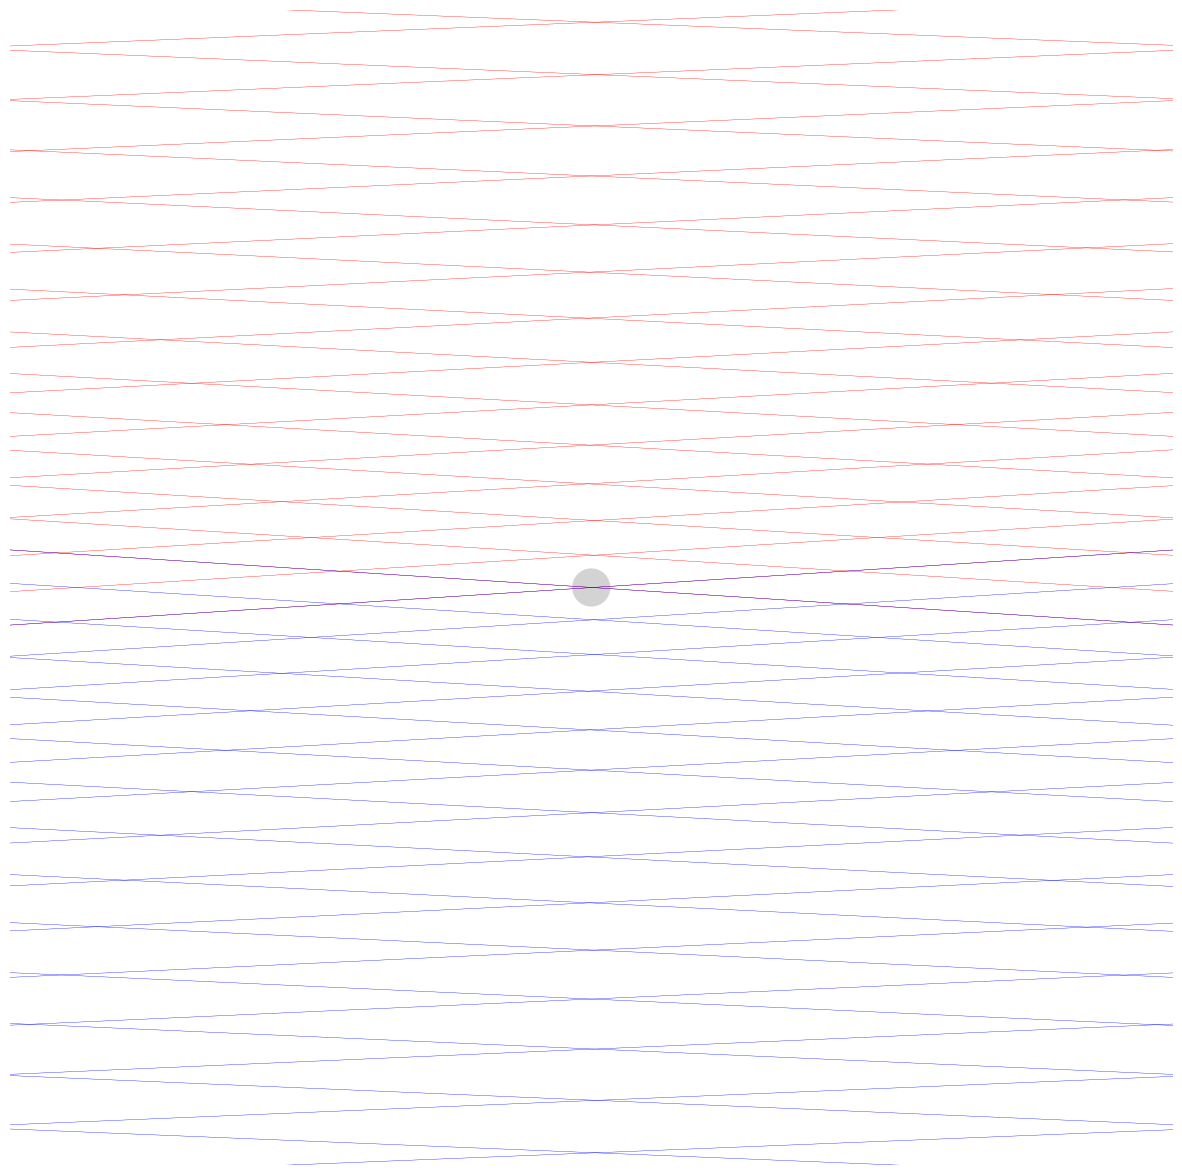

In [163]:
fig, ax = plt.subplots(1, figsize = (15, 15))

extrdiff1 = np.loadtxt('dataell/extreme1.csv', delimiter = ',')
extrdiff2 = np.loadtxt('dataell/extreme2.csv', delimiter = ',')
for row in extrdiff1: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.25, c = 'red')
for row in extrdiff2: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.25, c = 'blue')

if flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 2, color = 'black', label = 'target')
elif flat_source and not flat_target: plt.gca().add_patch(plt.Circle((0, 0), hl / np.pi, color = 'lightgrey', label = 'target'))
elif not flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 2, color = 'black', label = 'target')
elif not flat_source and not flat_target: plt.gca().add_patch(plt.Circle((0, 0), hl, color = 'lightgrey', label = 'target'))

plt.gca().add_patch(matplotlib.patches.Ellipse(xy = (-L / 2, 0), width = 2 * f1 + L, height = 2 * np.sqrt(f1 * (f1 + L)), fill = False, lw = 0.5))
plt.axis('equal')
zoom = hl * 10
plt.axis([-zoom, zoom, -zoom, zoom])
plt.axis('off')
plt.show()

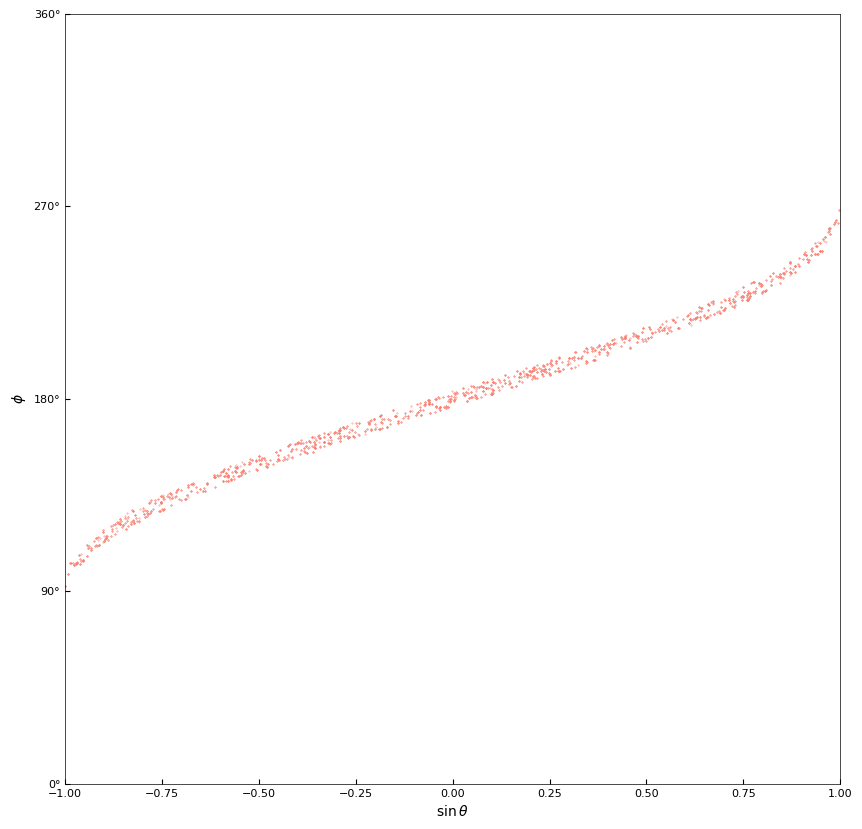

In [164]:
# cylindrical target
fig, ax = plt.subplots(1, figsize = (10, 10))
ax.tick_params(axis = 'x', direction = 'in', bottom = True, top = False, labelsize = 8)
ax.tick_params(axis = 'y', direction = 'in', left = True, right = False, labelsize = 8)
ax.set_yticks([0, 90, 180, 270, 360])
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}°"))
ax.spines['left'].set_position(('data', -1))
ax.spines['left'].set_bounds((0, 360))
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_bounds((-1, 1))
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['right'].set_position(('data', 1))
ax.spines['right'].set_bounds((0, 360))
ax.spines['right'].set_linewidth(0.5)
ax.spines['top'].set_position(('data', 360))
ax.spines['top'].set_bounds((-1, 1))
ax.spines['top'].set_linewidth(0.5)
phase_ellipse = np.loadtxt('dataell/phase.csv', delimiter = ',')
ax.scatter(phase_ellipse[:, 0], phase_ellipse[:, 1], s = 0.1, c = 'salmon')
ax.set_xlabel(r"$\sin\theta$")
ax.set_ylabel(r"$\phi$")
ax.set_xlim(-1, 1)
ax.set_ylim(0, 360)
plt.show()

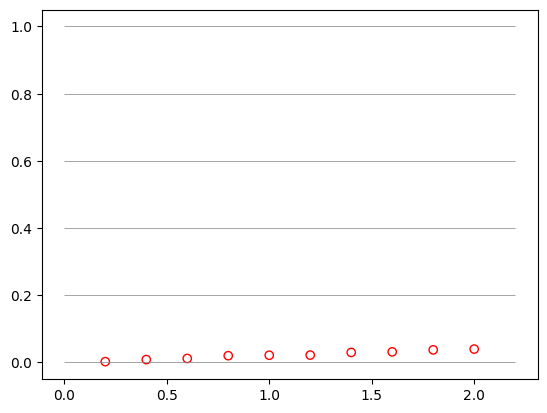

In [165]:
hitdata = np.loadtxt('dataell/hitdata.csv', delimiter = ',')
plt.scatter(hitdata[:, 0], hitdata[:, 1], facecolors = 'none', edgecolors = (1, 0, 0))
plt.hlines(y = [0, 0.2, 0.4, 0.6, 0.8, 1], xmin = 0, xmax = hitdata[-1, 0] + hitdata[0, 0], linewidth = 0.5, color = 'grey')
plt.show()